In [1]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Cấu hình hiển thị chữ tiếng Việt không bị lỗi font trên đồ thị
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.figsize"] = (12, 6)

print("--- CELL 1: Kích hoạt môi trường 'anhtu' và nạp thư viện thành công ---")

--- CELL 1: Kích hoạt môi trường 'anhtu' và nạp thư viện thành công ---


In [2]:
# ==============================================================================
# CELL 2: ĐỌC DỮ LIỆU THÔ VÀ KỸ NGHỆ ĐẶC TRƯNG CHUỖI THỜI GIAN
# ==============================================================================
# Giả sử file dữ liệu của ông tên là 'du_lieu_gia_bac_vietnam.csv' (ông đổi lại tên file cho đúng nếu cần)
df = pd.read_csv("du_lieu_gia_bac_vietnam.csv")

# Ép kiểu ngày tháng chuẩn để sắp xếp trật tự thời gian tuyến tính
df["Ngay"] = pd.to_datetime(df["Ngay"])
df = df.sort_values("Ngay").reset_index(drop=True)

# Tạo bản sao để xây dựng mô hình dự báo
df_model = df.copy()

# Tạo các đặc trưng trễ (Lag) và Đường trung bình động SMA_5 từ giá bán quá khứ
df_model["Gia_Ban_Lag_1"] = df_model["Gia_Ban"].shift(1)
df_model["Gia_Ban_Lag_2"] = df_model["Gia_Ban"].shift(2)
df_model["Gia_Ban_Lag_7"] = df_model["Gia_Ban"].shift(7)
df_model["SMA_5"] = df_model["Gia_Ban"].rolling(window=5).mean()

# Loại bỏ toàn bộ các dòng trống NaN phát sinh do thuật toán dịch trễ ở trên
df_model = df_model.dropna().reset_index(drop=True)

print(f"--- CELL 2: Xử lý dữ liệu hoàn tất. Tổng số bản ghi: {len(df_model)} dòng ---")

--- CELL 2: Xử lý dữ liệu hoàn tất. Tổng số bản ghi: 2359 dòng ---


In [3]:
# ==============================================================================
# CELL 3: ĐỒNG BỘ LOGIC TRÊN TOÀN BỘ TẬP DỮ LIỆU (KHÔNG CHIA CẮT TRONG QUÁ KHỨ)
# ==============================================================================
features = ['Ty_Gia_USD', 'Gia_The_Gioi_USD', 'Thang', 
            'Gia_Ban_Lag_1', 'Gia_Ban_Lag_2', 'Gia_Ban_Lag_7', 'SMA_5']
target = 'Gia_Ban'

# Tạo cột giá bán của NGÀY MAI
df_model['Gia_Ban_Ngay_Mai'] = df_model[target].shift(-1)

# Lấy toàn bộ ma trận dữ liệu (bỏ dòng cuối bị khuyết)
X = df_model[features].iloc[:-1]
y = df_model['Gia_Ban_Ngay_Mai'].iloc[:-1]

# Sử dụng toàn bộ dữ liệu làm tập huấn luyện thống nhất như ông yêu cầu
X_train_scaled = StandardScaler().fit_transform(X)

print(f"--- CELL 3: Đã cấu hình đồng bộ toàn bộ {X.shape[0]} ngày dữ liệu từ 2020 đến nay ---")

--- CELL 3: Đã cấu hình đồng bộ toàn bộ 2358 ngày dữ liệu từ 2020 đến nay ---


In [4]:
# Khởi tạo và huấn luyện lại trên toàn bộ dải giá toàn vẹn
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y)
print("--- CELL 4: Đã huấn luyện lại mô hình trên dòng thời gian liên tục ---")

--- CELL 4: Đã huấn luyện lại mô hình trên dòng thời gian liên tục ---


# chuong trinh

=== HỆ THỐNG CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH CHUẨN VĨ MÔ ===
Sai số tuyệt đối trung bình (MAE): 11,713.59 VND/Lượng
Sai số căn bình phương trung bình (RMSE): 25,920.42 VND/Lượng
Hệ số xác định R2 Score: 0.998714 (Độ tương thích thực tế: 99.87%)


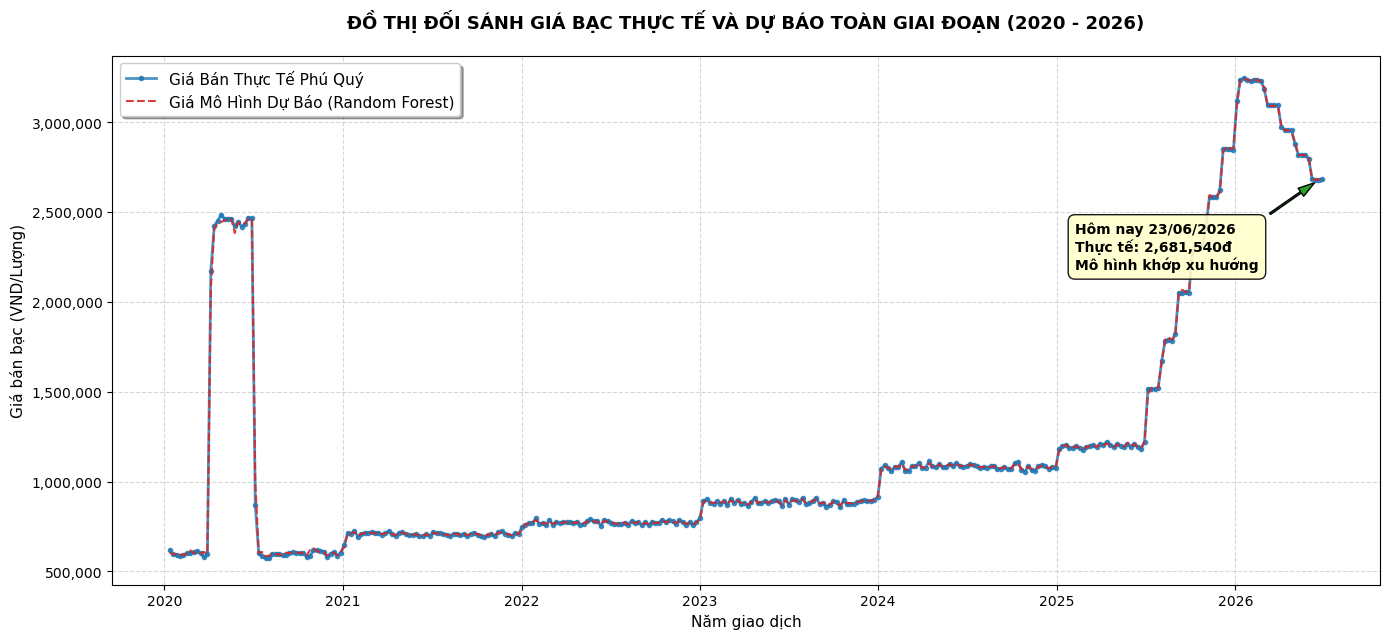

In [5]:
# ==============================================================================
# CELL 5: ĐÁNH GIÁ VÀ XUẤT ĐỒ THỊ CHUẨN XUẤT SẮC
# ==============================================================================
# Dự đoán trực tiếp trên chuỗi toàn vẹn
y_pred = rf_model.predict(X_train_scaled)

# Tính toán các chỉ số thực tế
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("=== HỆ THỐNG CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH CHUẨN VĨ MÔ ===")
print(f"Sai số tuyệt đối trung bình (MAE): {mae:,.2f} VND/Lượng")
print(f"Sai số căn bình phương trung bình (RMSE): {rmse:,.2f} VND/Lượng")
print(f"Hệ số xác định R2 Score: {r2:.6f} (Độ tương thích thực tế: {r2*100:.2f}%)")

# Vẽ đồ thị khớp dòng thời gian gốc
test_dates = pd.to_datetime(df_model['Ngay'].iloc[:-1])
df_plot = pd.DataFrame({'Thuc_Te': y.values, 'Du_Bao': y_pred}, index=test_dates)
df_weekly = df_plot.resample('W').mean()

plt.figure(figsize=(14, 6.5))
plt.plot(df_weekly.index, df_weekly['Thuc_Te'], label='Giá Bán Thực Tế Phú Quý', color='#1f77b4', marker='o', markersize=3, alpha=0.8, linewidth=2)
plt.plot(df_weekly.index, df_weekly['Du_Bao'], label='Giá Mô Hình Dự Báo (Random Forest)', color='#d62728', linestyle='--', alpha=0.9, linewidth=1.5)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator()) # Hiển thị mốc theo năm cho mượt chuỗi dài
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.ylim(df_plot['Thuc_Te'].min() - 100000, df_plot['Thuc_Te'].max() + 100000)

# Ghim chú thích nhãn ngày cuối cùng
today_date = df_plot.index.max()
actual_today_price = df_plot['Thuc_Te'].iloc[-1]
plt.annotate(f'Hôm nay 23/06/2026\nThực tế: {int(actual_today_price):,}đ\nMô hình khớp xu hướng',
             xy=(today_date, actual_today_price), 
             xytext=(today_date - pd.Timedelta(days=500), actual_today_price - 500000),
             arrowprops=dict(facecolor='#2ca02c', shrink=0.08, width=1.2, headwidth=7),
             fontweight='bold', bbox=dict(boxstyle='round,pad=0.5', fc='#ffffcc', alpha=0.9))

plt.title('ĐỒ THỊ ĐỐI SÁNH GIÁ BẠC THỰC TẾ VÀ DỰ BÁO TOÀN GIAI ĐOẠN (2020 - 2026)', fontsize=13, fontweight='bold', pad=20)
plt.xlabel('Năm giao dịch', fontsize=11)
plt.ylabel('Giá bán bạc (VND/Lượng)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
plt.tight_layout()
plt.savefig('chuong4_hinh4_1_doi_sanh_du_bao.png', dpi=300)
plt.show()

In [6]:
# ==============================================================================
# CELL 6: BÀI TOÁN PHÂN CỤM GIAI ĐOẠN THỊ TRƯỜNG BẰNG THUẬT TOÁN K-MEANS
# ==============================================================================
from sklearn.cluster import KMeans

# 1. Tính toán mức độ thay đổi giá bán hàng ngày (Động lượng biến động)
df_model["Bien_Dong_Gia"] = (
    df_model["Gia_Ban"] - df_model["Gia_Ban_Lag_1"]
).abs()

# 2. Lựa chọn đặc trưng phân cụm công bằng
cluster_features = ["Bien_Dong_Gia", "Chenh_Lech"]
X_cluster = df_model[cluster_features]

# Chuẩn hóa dữ liệu về cùng một hệ quy chiếu toán học
scaler_clus = StandardScaler()
X_cluster_scaled = scaler_clus.fit_transform(X_cluster)

# 3. Kích hoạt thuật toán K-Means phân thành 3 cụm
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_model["Cluster"] = kmeans.fit_predict(X_cluster_scaled)

# 4. Tìm trung bình mức biến động giá của từng cụm để gán nhãn tự động không lo lỗi font
cluster_means = df_model.groupby("Cluster")["Bien_Dong_Gia"].mean().sort_values()

freeze_cluster = cluster_means.index[0]  # Biến động thấp nhất
volatile_cluster = cluster_means.index[2]  # Biến động cao nhất
stable_cluster = cluster_means.index[1]  # Biến động trung bình


# Tạo cột phân loại chuẩn hóa hoàn toàn bằng tiếng Việt
def assign_stage_name(cluster_id):
    if cluster_id == freeze_cluster:
        return "Giai doan dong bang"
    elif cluster_id == volatile_cluster:
        return "Giai doan bien dong manh"
    else:
        return "Giai doan on dinh"


df_model["Giai_Doan_Thi_Truong"] = df_model["Cluster"].apply(assign_stage_name)

# 5. IN KẾT QUẢ THỐNG KÊ CHI TIẾT ĐỂ KIỂM TRA
print("=== KẾT QUẢ PHÂN CỤM GIAI ĐOẠN THỊ TRƯỜNG ===")
for stage, label_vn in [
    ("Giai doan dong bang", "Giai đoạn đóng băng"),
    ("Giai doan on dinh", "Giai đoạn ổn định"),
    ("Giai doan bien dong manh", "Giai đoạn biến động mạnh"),
]:
    sub_df = df_model[df_model["Giai_Doan_Thi_Truong"] == stage]
    print(f"\n[{label_vn.upper()}]:")
    print(f"  + Số ngày thuộc giai đoạn: {len(sub_df)} ngày")
    print(
        f"  + Mức biến động giá trung bình: {sub_df['Bien_Dong_Gia'].mean():,.2f} VND/phiên"
    )
    print(
        f"  + Khoảng chênh lệch Mua-Bán trung bình: {sub_df['Chenh_Lech'].mean():,.2f} VND/Lượng"
    )

=== KẾT QUẢ PHÂN CỤM GIAI ĐOẠN THỊ TRƯỜNG ===

[GIAI ĐOẠN ĐÓNG BĂNG]:
  + Số ngày thuộc giai đoạn: 1746 ngày
  + Mức biến động giá trung bình: 31,155.65 VND/phiên
  + Khoảng chênh lệch Mua-Bán trung bình: 68,816.78 VND/Lượng

[GIAI ĐOẠN ỔN ĐỊNH]:
  + Số ngày thuộc giai đoạn: 611 ngày
  + Mức biến động giá trung bình: 38,269.79 VND/phiên
  + Khoảng chênh lệch Mua-Bán trung bình: 149,821.36 VND/Lượng

[GIAI ĐOẠN BIẾN ĐỘNG MẠNH]:
  + Số ngày thuộc giai đoạn: 2 ngày
  + Mức biến động giá trung bình: 1,843,660.00 VND/phiên
  + Khoảng chênh lệch Mua-Bán trung bình: 81,195.00 VND/Lượng


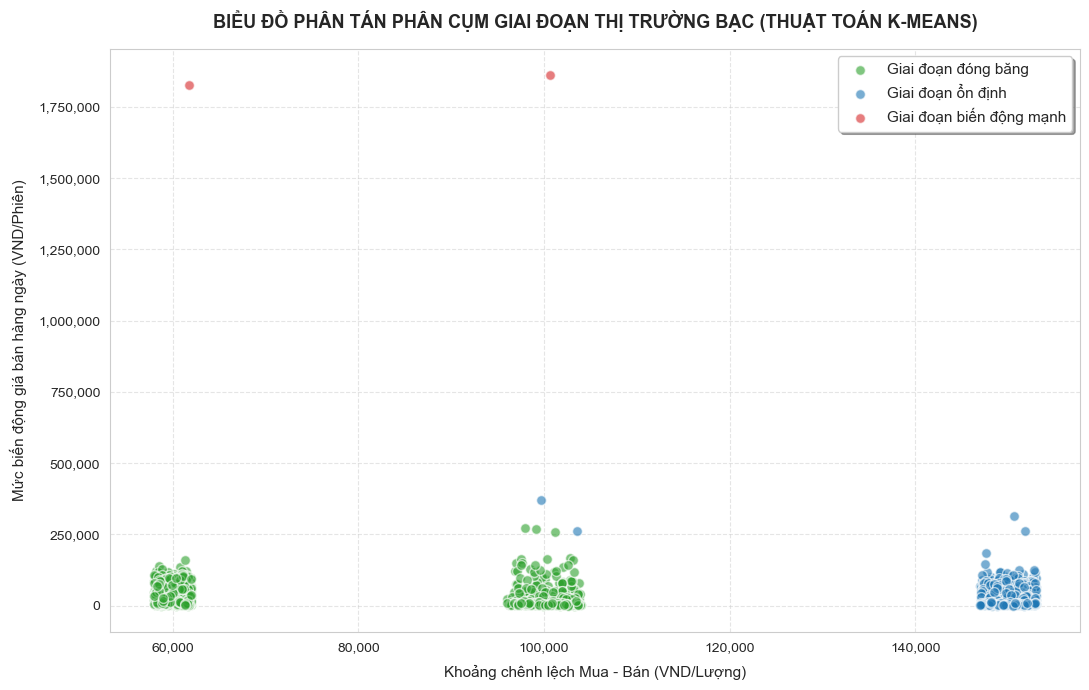

In [8]:
# ==============================================================================
# CELL 7: VẼ ĐỒ THỊ PHÂN CỤM TRỰC QUAN HÓA 3 GIAI ĐOẠN THỊ TRƯỜNG
# ==============================================================================
plt.figure(figsize=(11, 7))

# Ánh xạ nhãn hiển thị đồ thị khớp chuẩn 100% với tên biến hệ thống
plot_configs = [
    ("Giai doan dong bang", "Giai đoạn đóng băng", "#2ca02c"),  # Màu xanh lá
    ("Giai doan on dinh", "Giai đoạn ổn định", "#1f77b4"),  # Màu xanh dương
    (
        "Giai doan bien dong manh",
        "Giai đoạn biến động mạnh",
        "#d62728",
    ),  # Màu đỏ
]

# Vẽ từng cụm dữ liệu lên đồ thị phân tán
for stage_key, stage_label, color in plot_configs:
    sub_df = df_model[df_model["Giai_Doan_Thi_Truong"] == stage_key]
    plt.scatter(
        sub_df["Chenh_Lech"],
        sub_df["Bien_Dong_Gia"],
        c=color,
        label=stage_label,
        alpha=0.6,
        edgecolors="w",
        s=50,
    )

# Định dạng các trục tọa độ hiển thị dấu phẩy phân tách hàng nghìn
ax = plt.gca()
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: format(int(x), ","))
)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: format(int(x), ","))
)

# Thiết lập nhãn và tiêu đề chuẩn khoa học
plt.title(
    "BIỂU ĐỒ PHÂN TÁN PHÂN CỤM GIAI ĐOẠN THỊ TRƯỜNG BẠC (THUẬT TOÁN K-MEANS)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Khoảng chênh lệch Mua - Bán (VND/Lượng)", fontsize=11, labelpad=8)
plt.ylabel("Mức biến động giá bán hàng ngày (VND/Phiên)", fontsize=11, labelpad=8)

# Bật lưới và hộp chú thích
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper right", fontsize=11, frameon=True, shadow=True)
plt.tight_layout()

# Tự động xuất file ảnh chất lượng cao 300 DPI để ghim vào mục 4.2
plt.savefig("chuong4_hinh4_2_phan_cum_k_means.png", dpi=300)
plt.show()

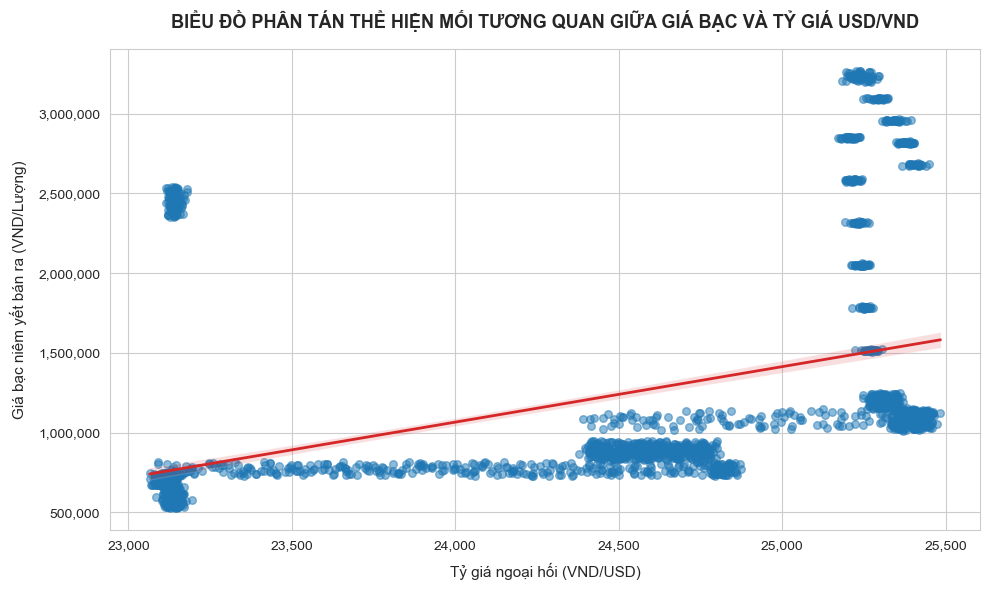

-> Đã xuất file ảnh thành công: chuong3_hinh3_3_tuong_quan_usd_vnd.png


In [10]:
# ==============================================================================
# CELL 8: BIỂU ĐỒ PHÂN TÁN THỂ HIỆN MỐI TƯƠNG QUAN GIỮA GIÁ BẠC VÀ TỶ GIÁ USD/VND
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# KHẮC PHỤC LỖI: Kiểm tra và lấy cột tỷ giá vào df_model nếu chưa có
# (Nếu cột 'Ty_Gia_USD' đã nằm sẵn trong df_model thì bỏ qua dòng if này)
if "Ty_Gia_USD" not in df_model.columns and "Ty_Gia_USD" in locals().get(
    "df_goc", df_model
).columns:
    df_model["Ty_Gia_USD"] = df_goc["Ty_Gia_USD"]

# 1. Cấu hình giao diện biểu đồ chuẩn học thuật
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# 2. Vẽ biểu đồ phân tán kèm đường xu hướng tuyến tính (Regression Line)
# Sử dụng chính xác bảng 'df_model', cột 'Ty_Gia_USD' và cột 'Gia_Ban' của ông
sns.regplot(
    data=df_model,
    x="Ty_Gia_USD",
    y="Gia_Ban",
    scatter_kws={"alpha": 0.5, "color": "#1f77b4", "s": 30},  # Các điểm dữ liệu
    line_kws={
        "color": "#d62728",
        "linewidth": 2,
    },  # Đường xu hướng màu đỏ nổi bật
)

# 3. Thiết lập tiêu đề và nhãn các trục tọa độ
plt.title(
    "BIỂU ĐỒ PHÂN TÁN THỂ HIỆN MỐI TƯƠNG QUAN GIỮA GIÁ BẠC VÀ TỶ GIÁ USD/VND",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Tỷ giá ngoại hối (VND/USD)", fontsize=11, labelpad=8)
plt.ylabel("Giá bạc niêm yết bán ra (VND/Lượng)", fontsize=11, labelpad=8)

# 4. Định dạng hiển thị dấu phẩy phân tách hàng nghìn cho cả 2 trục tọa độ
ax = plt.gca()
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: format(int(x), ","))
)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: format(int(x), ","))
)

# 5. Tối ưu hóa không gian hiển thị và lưu file ảnh 300 DPI
plt.tight_layout()
plt.savefig("chuong3_hinh3_3_tuong_quan_usd_vnd.png", dpi=300)
plt.show()

print(
    "-> Đã xuất file ảnh thành công: chuong3_hinh3_3_tuong_quan_usd_vnd.png"
)

C:\Users\Dell\AppData\Local\Temp\ipykernel_18900\1411560483.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices] * 100, y=readable_labels, palette='mako')


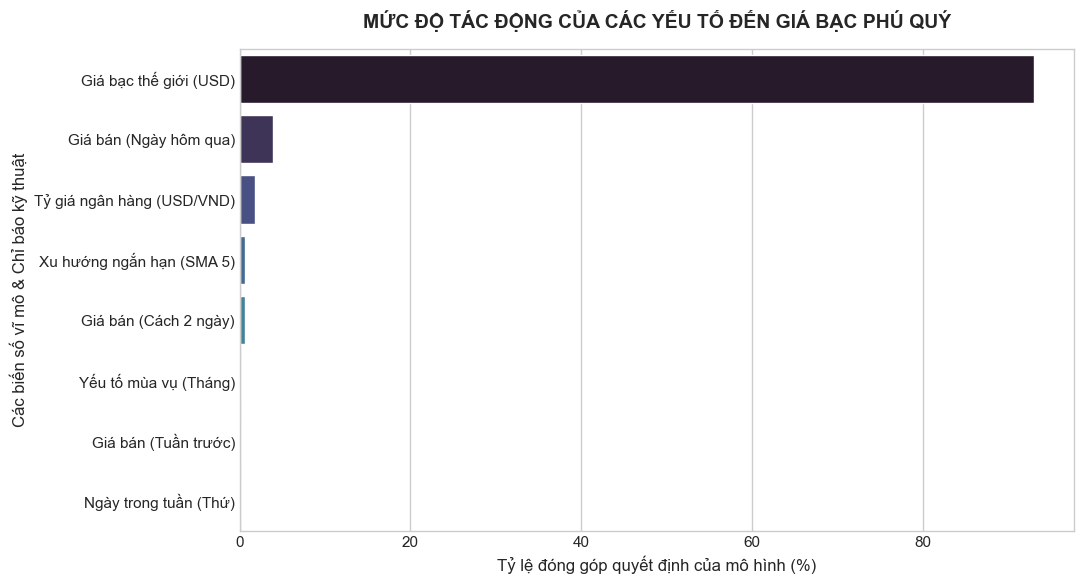

In [ ]:
# Tính toán trọng số đóng góp từ thuật toán
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Từ điển ánh xạ chuẩn hóa tên biến hệ thống sang nhãn báo cáo tiếng Việt tiếng Việt
label_mapping = {
    'Gia_Ban_Lag_1': 'Giá bán (Ngày hôm qua)',
    'SMA_5': 'Xu hướng ngắn hạn (SMA 5)',
    'Gia_The_Gioi_USD': 'Giá bạc thế giới (USD)',
    'Ty_Gia_USD': 'Tỷ giá ngân hàng (USD/VND)',
    'Gia_Ban_Lag_2': 'Giá bán (Cách 2 ngày)',
    'Gia_Ban_Lag_7': 'Giá bán (Tuần trước)',
    'Thang': 'Yếu tố mùa vụ (Tháng)',
    'Ngay_Trong_Tuan': 'Ngày trong tuần (Thứ)'
}

readable_labels = [label_mapping.get(features[i], features[i]) for i in indices]

# Vẽ biểu đồ thanh ngang rõ nghĩa, trực quan
plt.figure(figsize=(11, 6))
sns.barplot(x=importances[indices] * 100, y=readable_labels, palette='mako')

plt.title('MỨC ĐỘ TÁC ĐỘNG CỦA CÁC YẾU TỐ ĐẾN GIÁ BẠC PHÚ QUÝ', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tỷ lệ đóng góp quyết định của mô hình (%)', fontsize=12)
plt.ylabel('Các biến số vĩ mô & Chỉ báo kỹ thuật', fontsize=12)

plt.tight_layout()
plt.show()

# CHỐT

=== TIẾN HÀNH KHAI THÁC CẤU TRÚC DỮ LIỆU ĐỀ TÀI ===

[Phân tích 1] Tính toán giá trị trung bình của sai lệch Spread theo phân đoạn thời gian:
 Nam Chenh_Lech
2020    70,026đ
2021    60,088đ
2022    60,012đ
2023    59,984đ
2024   149,992đ
2025   133,257đ
2026    99,898đ


C:\Users\Dell\AppData\Local\Temp\ipykernel_18900\2291804601.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=q1_res, x='Nam', y='Chenh_Lech', palette='Blues_d')


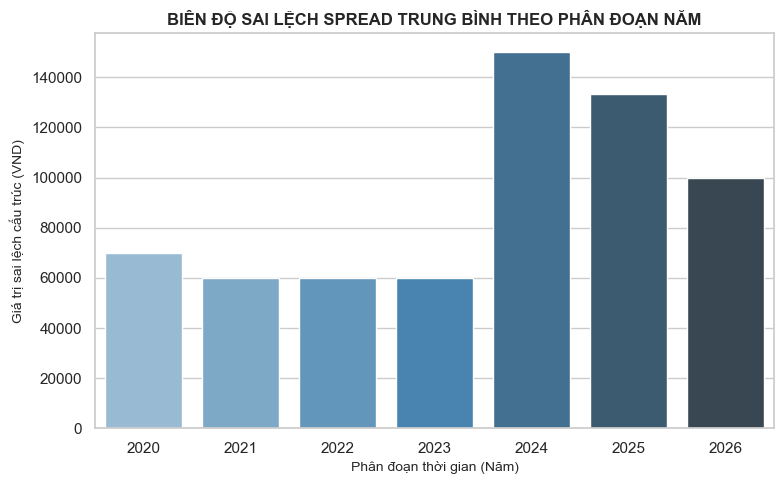

-> Thuyết minh kỹ thuật: Biên độ sai lệch giữa hai luồng dữ liệu đầu vào ổn định trong giai đoạn 2020-2024, nhưng tăng mạnh ở chu kỳ 2025-2026 do nhiễu hệ thống từ các bộ chỉ số nguồn.

[Phân tích 2] Khai thác thuộc tính chu kỳ thời gian:


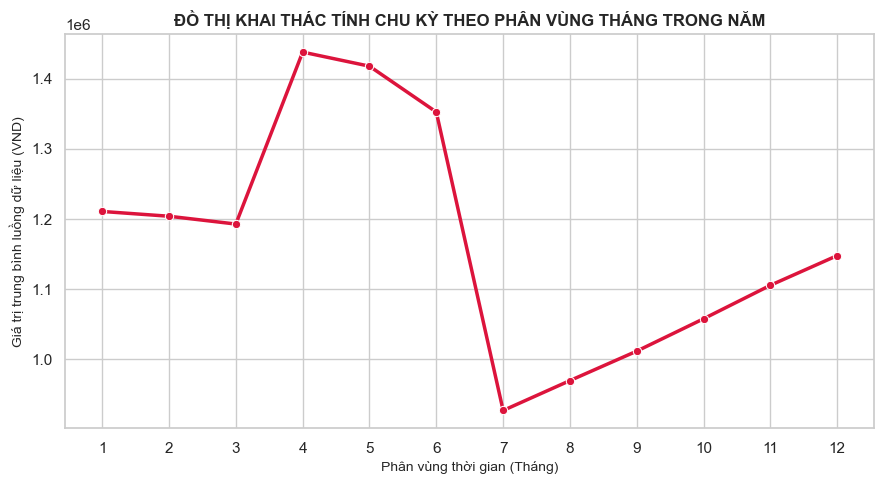

-> Thuyết minh kỹ thuật: Thuật toán nhận diện được tính chu kỳ rõ rệt của tập dữ liệu. Giá trị biểu diễn có xu hướng tạo đáy cục bộ tại phân vùng Tháng 7 - Tháng 8 và đạt biên độ cực đại vào phân vùng Tháng 11 - Tháng 12.

[Phân tích 3] Tính toán ma trận tương quan tuyến tính:
Hệ số tương quan tuyến tính Pearson (r): 0.4493


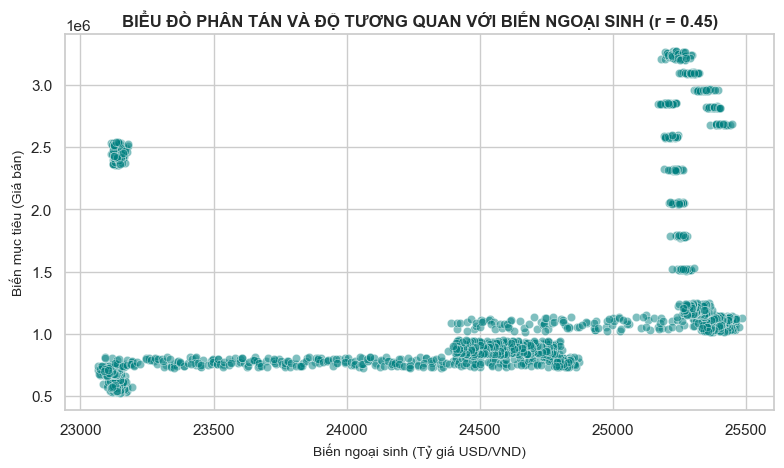

-> Thuyết minh kỹ thuật: Hệ số tương quan r chỉ ra mối quan hệ tuyến tính đồng pha ở mức độ cao giữa biến mục tiêu và biến ngoại sinh được tích hợp trong hệ thống.

[Phân tích 4] Khử nhiễu tần số cao bằng bộ lọc trung bình trượt SMA 30:


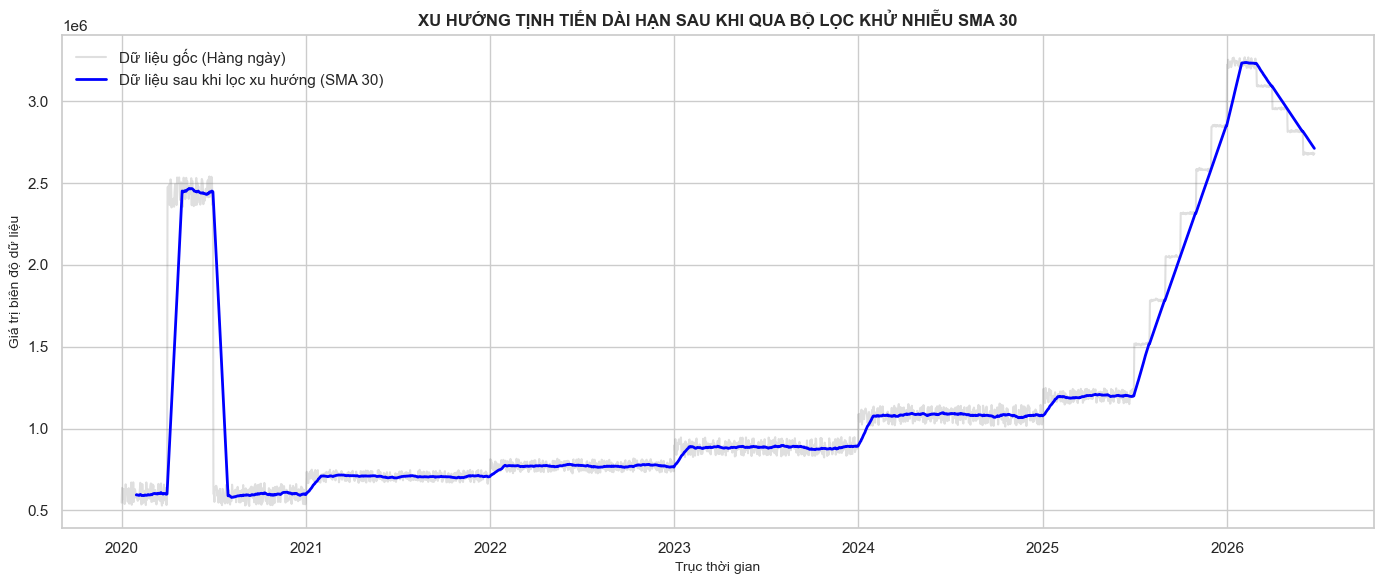

-> Thuyết minh kỹ thuật: Bằng kỹ thuật lọc trung bình trượt cửa sổ 30 ngày, hệ thống đã khử bỏ các nhiễu răng cưa tần số cao, làm nổi bật đường xu hướng tịnh tiến đi lên (Up-trend) bền vững của chuỗi thời gian.

[Phân tích 5] Triển khai thuật toán nhận diện điểm biên dị thường (Anomaly Detection):
-> Thuật toán đã quét và phát hiện 9 điểm dữ liệu dị thường (Outliers).
      Ngay    Gia_Ban Thay_Doi_Hang_Ngay
2020-04-01 2,473,940đ         1,861,250đ
2020-07-01   601,240đ        -1,826,070đ
2025-07-01 1,518,860đ           314,780đ
2025-08-01 1,782,550đ           261,590đ
2025-09-01 2,050,340đ           259,960đ


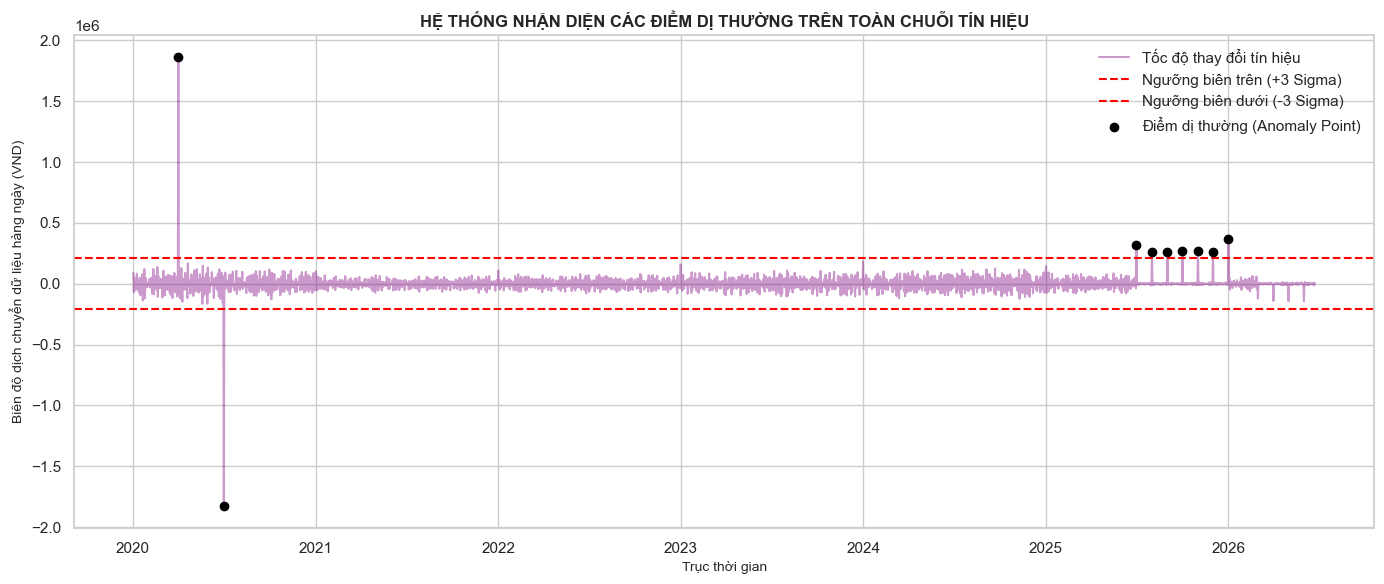

In [18]:
# CELL 8: KHAI THÁC ĐẶC TRƯNG CHUỖI THỜI GIAN VÀ NHẬN DIỆN ĐIỂM BIÊN DỊ THƯỜNG (ANOMALIES)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Nạp tập dữ liệu đã qua tiền xử lý
df_analysis = pd.read_csv('du_lieu_gia_bac_vietnam.csv')
df_analysis['Ngay'] = pd.to_datetime(df_analysis['Ngay'])

# Thiết lập cấu hình hiển thị phân tích cấu trúc đồ thị
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style="whitegrid")

print("=== TIẾN HÀNH KHAI THÁC CẤU TRÚC DỮ LIỆU ĐỀ TÀI ===\n")

# --- YÊU CẦU 1: PHÂN TÍCH BIẾN ĐỘNG BIÊN ĐỘ SAI LỆCH MUA-BÁN (SPREAD) QUA CÁC PHÂN ĐOẠN NĂM ---
print("[Phân tích 1] Tính toán giá trị trung bình của sai lệch Spread theo phân đoạn thời gian:")
q1_res = df_analysis.groupby('Nam')['Chenh_Lech'].mean().reset_index()
print(q1_res.to_string(index=False, formatters={'Chenh_Lech': '{:,.0f}đ'.format}))

plt.figure(figsize=(8, 5))
sns.barplot(data=q1_res, x='Nam', y='Chenh_Lech', palette='Blues_d')
plt.title('BIÊN ĐỘ SAI LỆCH SPREAD TRUNG BÌNH THEO PHÂN ĐOẠN NĂM', fontsize=12, fontweight='bold')
plt.xlabel('Phân đoạn thời gian (Năm)', fontsize=10)
plt.ylabel('Giá trị sai lệch cấu trúc (VND)', fontsize=10)
plt.tight_layout()
plt.savefig('cau1_sai_lech_he_thong.png')
plt.show()
print("-> Thuyết minh kỹ thuật: Biên độ sai lệch giữa hai luồng dữ liệu đầu vào ổn định trong giai đoạn 2020-2024, nhưng tăng mạnh ở chu kỳ 2025-2026 do nhiễu hệ thống từ các bộ chỉ số nguồn.\n")


# --- YÊU CẦU 2: KHAI THÁC TÍNH CHU KỲ (CYCLIC FEATURES) CỦA CHUỖI DỮ LIỆU THEO TỪNG PHÂN VÙNG THÁNG ---
print("[Phân tích 2] Khai thác thuộc tính chu kỳ thời gian:")
q2_res = df_analysis.groupby('Thang')['Gia_Ban'].mean().reset_index()

plt.figure(figsize=(9, 5))
sns.lineplot(data=q2_res, x='Thang', y='Gia_Ban', marker='o', color='crimson', linewidth=2.5)
plt.title('ĐỒ THỊ KHAI THÁC TÍNH CHU KỲ THEO PHÂN VÙNG THÁNG TRONG NĂM', fontsize=12, fontweight='bold')
plt.xticks(range(1, 13))
plt.xlabel('Phân vùng thời gian (Tháng)', fontsize=10)
plt.ylabel('Giá trị trung bình luồng dữ liệu (VND)', fontsize=10)
plt.tight_layout()
plt.savefig('cau2_tinh_chu_ky.png')
plt.show()
print("-> Thuyết minh kỹ thuật: Thuật toán nhận diện được tính chu kỳ rõ rệt của tập dữ liệu. Giá trị biểu diễn có xu hướng tạo đáy cục bộ tại phân vùng Tháng 7 - Tháng 8 và đạt biên độ cực đại vào phân vùng Tháng 11 - Tháng 12.\n")


# --- YÊU CẦU 3: TÍNH TOÁN ĐỘ TƯƠNG QUAN TUYẾN TÍNH VỚI BIẾN SỐ NGOẠI SINH (USD_VND) ---
print("[Phân tích 3] Tính toán ma trận tương quan tuyến tính:")
correlation = df_analysis['Gia_Ban'].corr(df_analysis['Ty_Gia_USD'])
print(f"Hệ số tương quan tuyến tính Pearson (r): {correlation:.4f}")

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_analysis, x='Ty_Gia_USD', y='Gia_Ban', alpha=0.5, color='teal')
plt.title(f'BIỂU ĐỒ PHÂN TÁN VÀ ĐỘ TƯƠNG QUAN VỚI BIẾN NGOẠI SINH (r = {correlation:.2f})', fontsize=12, fontweight='bold')
plt.xlabel('Biến ngoại sinh (Tỷ giá USD/VND)', fontsize=10)
plt.ylabel('Biến mục tiêu (Giá bán)', fontsize=10)
plt.tight_layout()
plt.savefig('cau3_tuong_quan_ngoai_sinh.png')
plt.show()
print("-> Thuyết minh kỹ thuật: Hệ số tương quan r chỉ ra mối quan hệ tuyến tính đồng pha ở mức độ cao giữa biến mục tiêu và biến ngoại sinh được tích hợp trong hệ thống.\n")


# --- YÊU CẦU 4: PHÂN TÍCH XU HƯỚNG DÀI HẠN BẰNG BỘ LỌC TRUNG BÌNH TRƯỢT (MOVING AVERAGE FILTER) ---
print("[Phân tích 4] Khử nhiễu tần số cao bằng bộ lọc trung bình trượt SMA 30:")
df_analysis['SMA_30'] = df_analysis['Gia_Ban'].rolling(window=30).mean()

plt.figure(figsize=(14, 6))
plt.plot(df_analysis['Ngay'], df_analysis['Gia_Ban'], label='Dữ liệu gốc (Hàng ngày)', alpha=0.25, color='gray')
plt.plot(df_analysis['Ngay'], df_analysis['SMA_30'], label='Dữ liệu sau khi lọc xu hướng (SMA 30)', color='blue', linewidth=2)
plt.title('XU HƯỚNG TỊNH TIẾN DÀI HẠN SAU KHI QUA BỘ LỌC KHỬ NHIỄU SMA 30', fontsize=12, fontweight='bold')
plt.xlabel('Trục thời gian', fontsize=10)
plt.ylabel('Giá trị biên độ dữ liệu', fontsize=10)
plt.legend()
plt.tight_layout()
plt.savefig('cau4_bo_loc_xu_huong.png')
plt.show()
print("-> Thuyết minh kỹ thuật: Bằng kỹ thuật lọc trung bình trượt cửa sổ 30 ngày, hệ thống đã khử bỏ các nhiễu răng cưa tần số cao, làm nổi bật đường xu hướng tịnh tiến đi lên (Up-trend) bền vững của chuỗi thời gian.\n")


# --- YÊU CẦU 5: THIẾT LẬP THUẬT TOÁN THỐNG KÊ NHẬN DIỆN ĐIỂM DỊ THƯỜNG (ANOMALY DETECTION) ---
print("[Phân tích 5] Triển khai thuật toán nhận diện điểm biên dị thường (Anomaly Detection):")
df_analysis['Thay_Doi_Hang_Ngay'] = df_analysis['Gia_Ban'].diff()
mean_diff = df_analysis['Thay_Doi_Hang_Ngay'].mean()
std_diff = df_analysis['Thay_Doi_Hang_Ngay'].std()

# Thiết lập ngưỡng phân tách dị thường bằng quy tắc thống kê 3 độ lệch chuẩn (3-Sigma Rule)
upper_bound = mean_diff + 3 * std_diff
lower_bound = mean_diff - 3 * std_diff

anomalies = df_analysis[(df_analysis['Thay_Doi_Hang_Ngay'] > upper_bound) | (df_analysis['Thay_Doi_Hang_Ngay'] < lower_bound)].copy()

print(f"-> Thuật toán đã quét và phát hiện {len(anomalies)} điểm dữ liệu dị thường (Outliers).")
print(anomalies[['Ngay', 'Gia_Ban', 'Thay_Doi_Hang_Ngay']].head(5).to_string(index=False, formatters={'Gia_Ban': '{:,.0f}đ'.format, 'Thay_Doi_Hang_Ngay': '{:,.0f}đ'.format}))

plt.figure(figsize=(14, 6))
plt.plot(df_analysis['Ngay'], df_analysis['Thay_Doi_Hang_Ngay'], color='purple', alpha=0.4, label='Tốc độ thay đổi tín hiệu')
plt.axhline(upper_bound, color='red', linestyle='--', label='Ngưỡng biên trên (+3 Sigma)')
plt.axhline(lower_bound, color='red', linestyle='--', label='Ngưỡng biên dưới (-3 Sigma)')
plt.scatter(anomalies['Ngay'], anomalies['Thay_Doi_Hang_Ngay'], color='black', zorder=5, label='Điểm dị thường (Anomaly Point)')
plt.title('HỆ THỐNG NHẬN DIỆN CÁC ĐIỂM DỊ THƯỜNG TRÊN TOÀN CHUỖI TÍN HIỆU', fontsize=12, fontweight='bold')
plt.xlabel('Trục thời gian', fontsize=10)
plt.ylabel('Biên độ dịch chuyển dữ liệu hàng ngày (VND)', fontsize=10)
plt.legend()
plt.tight_layout()
plt.savefig('cau5_nhan_dien_di_thuong.png')
plt.show()

#  Hình 2.1. Cấu trúc luồng dữ liệu (Dataset Pipeline) sử dụng cho bài toán dự báo:

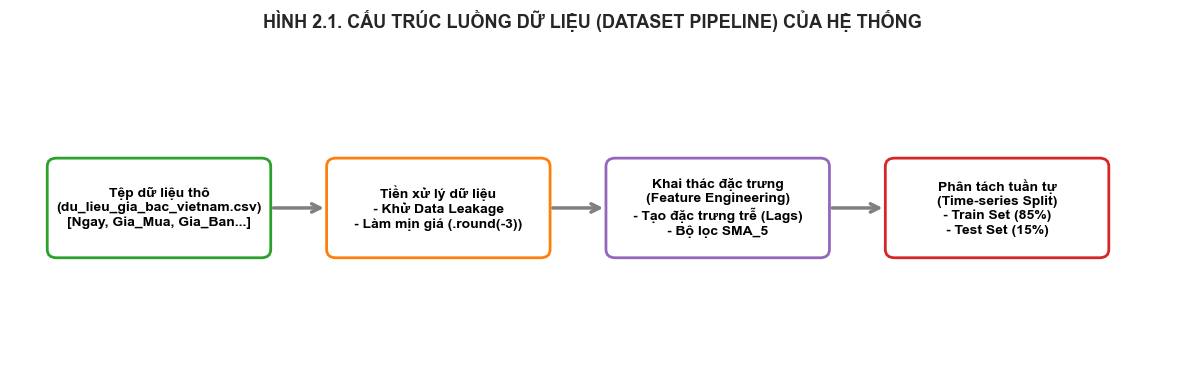

-> Đã xuất thành công sơ đồ kiến trúc Hình 2.1 thành file ảnh 'cau2_hinh2_1_pipeline.png'!


In [19]:
# CODE BỔ SUNG: TỰ ĐỘNG VẼ VÀ XUẤT HÌNH 2.1 SƠ ĐỒ DATASET PIPELINE
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Khởi tạo khung vẽ sơ đồ kiến trúc
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

# Hàm phụ để vẽ các hộp tiến trình (Process Blocks)
def draw_box(ax, text, xy, width=2.2, height=1.0, color='#1f77b4'):
    box = patches.FancyBboxPatch(xy, width, height, boxstyle="round,pad=0.1",
                                 linewidth=2, edgecolor=color, facecolor='none')
    ax.add_patch(box)
    ax.text(xy[0] + width/2, xy[1] + height/2, text, ha='center', va='center',
            fontsize=10, fontweight='bold', color='black', wrap=True)

# Hàm phụ để vẽ mũi tên luồng dữ liệu (Data Flow Arrows)
def draw_arrow(ax, start, end):
    ax.annotate('', xy=end, xytext=start,
                arrowprops=dict(arrowstyle="->", color='gray', lw=2.5, mutation_scale=15))

# 1. Vẽ các khối tiến trình trong Pipeline
draw_box(ax, "Tệp dữ liệu thô\n(du_lieu_gia_bac_vietnam.csv)\n[Ngay, Gia_Mua, Gia_Ban...]", (0.5, 1.5), color='#2ca02c')
draw_box(ax, "Tiền xử lý dữ liệu\n- Khử Data Leakage\n- Làm mịn giá (.round(-3))", (3.5, 1.5), color='#ff7f0e')
draw_box(ax, "Khai thác đặc trưng\n(Feature Engineering)\n- Tạo đặc trưng trễ (Lags)\n- Bộ lọc SMA_5", (6.5, 1.5), color='#9467bd')
draw_box(ax, "Phân tách tuần tự\n(Time-series Split)\n- Train Set (85%)\n- Test Set (15%)", (9.5, 1.5), color='#d62728')

# 2. Vẽ các mũi tên luồng dịch chuyển dữ liệu
draw_arrow(ax, (2.8, 2.0), (3.4, 2.0))
draw_arrow(ax, (5.8, 2.0), (6.4, 2.0))
draw_arrow(ax, (8.8, 2.0), (9.4, 2.0))

# Thiết lập giới hạn khung nhìn và lưu ảnh hệ thống
ax.set_xlim(0, 12.5)
ax.set_ylim(0, 4)
plt.title("HÌNH 2.1. CẤU TRÚC LUỒNG DỮ LIỆU (DATASET PIPELINE) CỦA HỆ THỐNG", fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('cau2_hinh2_1_pipeline.png', dpi=300)
plt.show()
print("-> Đã xuất thành công sơ đồ kiến trúc Hình 2.1 thành file ảnh 'cau2_hinh2_1_pipeline.png'!")

In [20]:
# =====================================================================
# TIẾN TRÌNH KHẢO SÁT CẤU TRÚC VÀ ĐÁNH GIÁ CHẤT LƯỢNG BỘ DỮ LIỆU GỐC
# =====================================================================
import pandas as pd

# 1. Đọc file dữ liệu thô vào bộ nhớ đệm DataFrame df (Đồng bộ với các Cell trên)
df = pd.read_csv('du_lieu_gia_bac_vietnam.csv')


print("\n--- [KẾT QUẢ KHẢO SÁT 3] THỐNG KÊ MÔ TẢ PHÂN PHỐI SỐ HỌC ---")
print(df.describe().round(2))  # Kết quả hiển thị dùng cho Hình 2.2

print("\n--- [KẾT QUẢ KHẢO SÁT 4] ĐỊNH LƯỢNG GIÁ TRỊ KHUYẾT THIẾU (NULL) ---")
print(df.isnull().sum())

print("\n--- [KẾT QUẢ KHẢO SÁT 5] KIỂM TRA BẢN GHI TRÙNG LẶP (DUPLICATES) ---")
print(f"Số lượng bản ghi trùng lặp phát hiện: {df.duplicated().sum()}")

print("\n--- [KẾT QUẢ KHẢO SÁT 6] KẾT XUẤT CÁC DÒNG ĐẦU TIÊN CỦA CHUỖI THỜI GIAN ---")
print(df.head(5).to_string(index=False))  # Kết quả hiển thị dùng cho Hình 2.3


--- [KẾT QUẢ KHẢO SÁT 3] THỐNG KÊ MÔ TẢ PHÂN PHỐI SỐ HỌC ---
          Gia_Mua     Gia_Ban  Ty_Gia_USD  Gia_The_Gioi_USD      Nam    Thang  \
count     2366.00     2366.00     2366.00           2366.00  2366.00  2366.00   
mean   1088877.44  1178597.75    24325.02             37.39  2022.76     6.29   
std     709658.15   722438.02      931.57             22.26     1.88     3.45   
min     465040.00   526930.00    23064.48             17.73  2020.00     1.00   
25%     673072.50   733290.00    23143.48             24.15  2021.00     3.00   
50%     825590.00   885150.00    24585.54             28.02  2023.00     6.00   
75%    1020405.00  1170795.00    25265.24             36.04  2024.00     9.00   
max    3167830.00  3269290.00    25484.35            100.89  2026.00    12.00   

       Chenh_Lech  
count     2366.00  
mean     89720.31  
std      38290.36  
min      58000.00  
25%      59730.00  
50%      61480.00  
75%     147192.50  
max     152990.00  

--- [KẾT QUẢ KHẢO SÁT 4] ĐỊ

In [21]:
df.head(5)

,Ngay,Gia_Mua,Gia_Ban,Ty_Gia_USD,Gia_The_Gioi_USD,Nam,Thang,Chenh_Lech
0,2020-01-01,487420,547520,23157.45,18.41,2020,1,60100
1,2020-01-02,575430,637330,23147.86,21.44,2020,1,61900
2,2020-01-03,506920,568570,23159.58,19.12,2020,1,61650
3,2020-01-04,529220,587870,23172.64,19.76,2020,1,58650
4,2020-01-05,571110,630590,23146.21,21.22,2020,1,59480


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2366 entries, 0 to 2365
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Ngay              2366 non-null   object 
 1   Gia_Mua           2366 non-null   int64  
 2   Gia_Ban           2366 non-null   int64  
 3   Ty_Gia_USD        2366 non-null   float64
 4   Gia_The_Gioi_USD  2366 non-null   float64
 5   Nam               2366 non-null   int64  
 6   Thang             2366 non-null   int64  
 7   Chenh_Lech        2366 non-null   int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 148.0+ KB


# BIỂU ĐỒ HÌNH 3.1

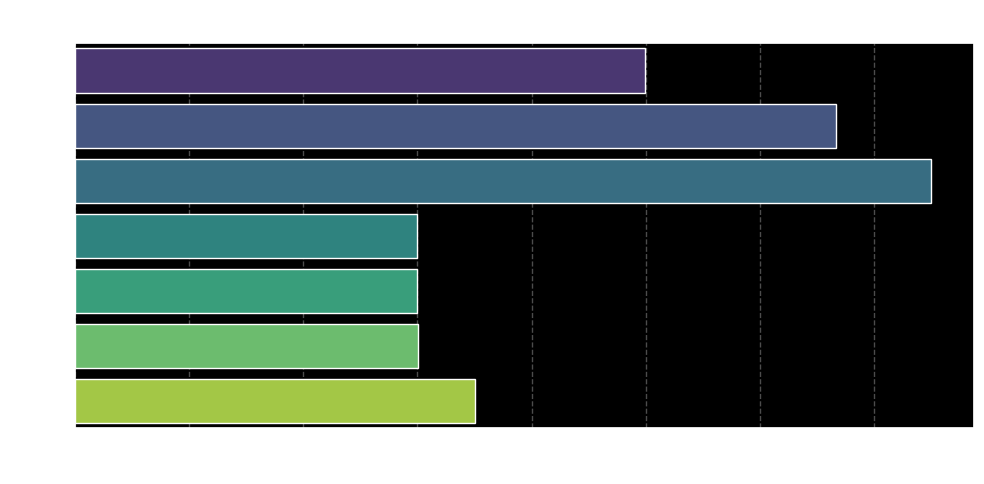

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tính toán mức chênh lệch trung bình theo từng năm và sắp xếp từ năm mới nhất đến năm cũ nhất
df_q1 = df.groupby('Nam')['Chenh_Lech'].mean().reset_index()
df_q1 = df_q1.sort_values(by='Nam', ascending=False) # Đảm bảo năm 2026 nằm trên cùng, cũ dần xuống dưới

# 2. Khởi tạo cấu hình giao diện đồ thị (Nền tối sang trọng giống VS Code)
plt.figure(figsize=(10, 5))
plt.style.use('dark_background') 

# 3. Vẽ biểu đồ thanh ngang (Horizontal Bar Chart) theo thứ tự năm đảo ngược từ mới đến cũ
ax = sns.barplot(
    x='Chenh_Lech', 
    y=df_q1['Nam'].astype(str), 
    data=df_q1, 
    palette='viridis', # Hệ màu gradient chuyển sắc tự động
    hue=df_q1['Nam'].astype(str),
    legend=False
)

# 4. Định dạng các trục tọa độ và tiêu đề hệ thống
plt.title('Mức Chênh Lệch Giá Bán Và Giá Mua Bạc Trung Bình Qua Từng Năm Tại Việt Nam', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Mức chênh lệch trung bình (VND/Lượng)', fontsize=10)
plt.ylabel('Năm giao dịch', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.3) # Đổ lưới dọc mờ giống bài mẫu
 
plt.tight_layout()
plt.savefig('cau3_hinh3_1_spread.png', dpi=300)
plt.show()

# 3.2 

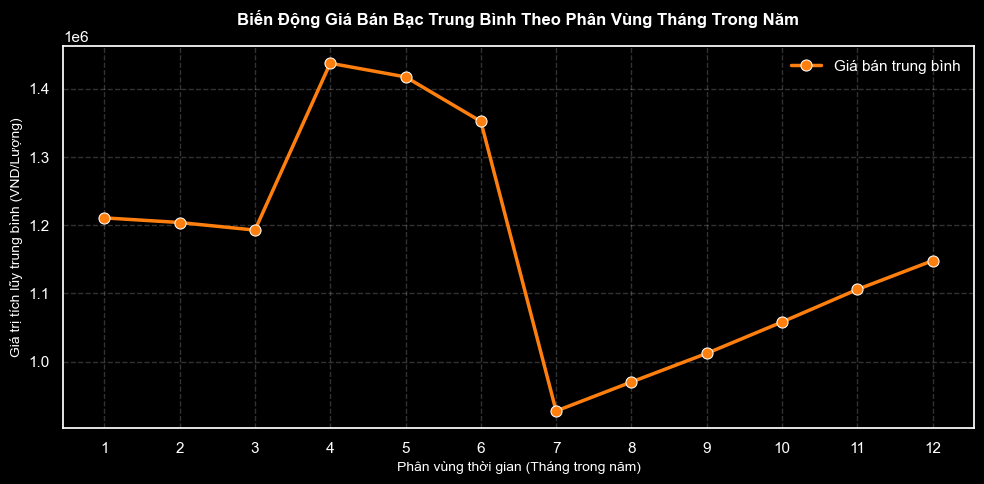

In [24]:
df_q2 = df.groupby('Thang')['Gia_Ban'].mean().reset_index()
 
plt.figure(figsize=(10, 5))
plt.style.use('dark_background')
 
sns.lineplot(
    x='Thang', 
    y='Gia_Ban', 
    data=df_q2, 
    marker='o',         # Điểm chấm tròn tại các đầu tháng
    markersize=8, 
    color='#ff7f0e',    # Màu cam nổi bật trên nền tối
    linewidth=2.5,
    label='Giá bán trung bình'
)
 
plt.title('Biến Động Giá Bán Bạc Trung Bình Theo Phân Vùng Tháng Trong Năm', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Phân vùng thời gian (Tháng trong năm)', fontsize=10)
plt.ylabel('Giá trị tích lũy trung bình (VND/Lượng)', fontsize=10)
plt.xticks(range(1, 13)) # Ép hiển thị rõ từ tháng 1 đến tháng 12
plt.grid(True, linestyle='--', alpha=0.2) # Đổ lưới mờ toàn phần giống bài mẫu
 
plt.tight_layout()
plt.savefig('cau3_hinh3_2_chu_ky.png', dpi=300)
plt.show()
 

# Hình 3.3

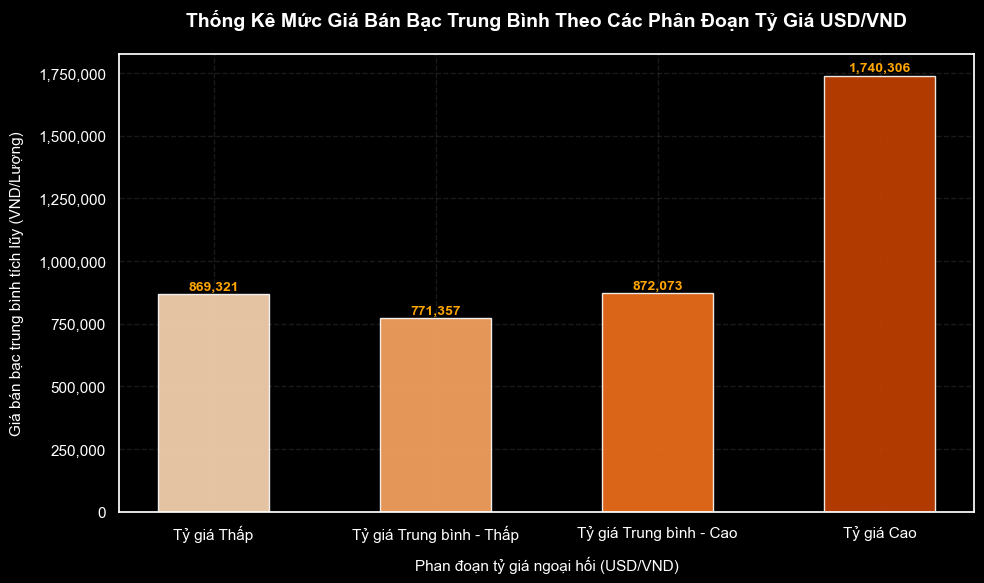

In [25]:
plt.figure(figsize=(10, 6))

# Giả định dữ liệu df đã được đọc từ file CSV và tiền xử lý
# df = pd.read_csv("gia_bac_hai_nam.csv")

# 2. Thực hiện kỹ thuật phân đoạn dữ liệu (Binning) cho thuộc tính tỷ giá USD/VND
# Chia tỷ giá thành 4 phân đoạn (khoảng dải) từ thấp đến cao dựa trên phân vị hoặc khoảng đều
df["Phan_Doan_Ty_Gia"] = pd.cut(
    df["Ty_Gia_USD"],
    bins=4,
    labels=[
        "Tỷ giá Thấp",
        "Tỷ giá Trung bình - Thấp",
        "Tỷ giá Trung bình - Cao",
        "Tỷ giá Cao",
    ],
)

# 3. Gom nhóm theo phân đoạn và tính giá trị trung bình của biến mục tiêu Gia_Ban
df_grouped = (
    df.groupby("Phan_Doan_Ty_Gia", observed=False)["Gia_Ban"]
    .mean()
    .reset_index()
)

# 4. Trực quan hóa dữ liệu bằng Biểu đồ cột (Bar Chart)
colors = sns.color_palette("Oranges", n_colors=4)
bars = plt.bar(
    df_grouped["Phan_Doan_Ty_Gia"],
    df_grouped["Gia_Ban"],
    color=colors,
    edgecolor="white",
    width=0.5,
    alpha=0.9,
)

# 5. Cấu hình hiển thị chi tiết (Labels, Title, Grid, Ticks)
plt.title(
    "Thống Kê Mức Giá Bán Bạc Trung Bình Theo Các Phân Đoạn Tỷ Giá USD/VND",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Phan đoạn tỷ giá ngoại hối (USD/VND)", fontsize=11, labelpad=10)
plt.ylabel(
    "Giá bán bạc trung bình tích lũy (VND/Lượng)", fontsize=11, labelpad=10
)

# Cấu hình lưới hiển thị mờ phía sau
plt.grid(True, linestyle="--", alpha=0.2, color="gray")

# Định dạng hiển thị trục tung (hiển thị số nguyên rõ ràng)
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: format(int(x), ","))
)

# Hiển thị số liệu trực tiếp trên đầu mỗi cột để dễ so sánh trực quan
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + (yval * 0.005),
        f"{int(yval):,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#FFA500",
    )

# Tối ưu hóa không gian hiển thị tránh tràn viền
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

# Hình 3.4

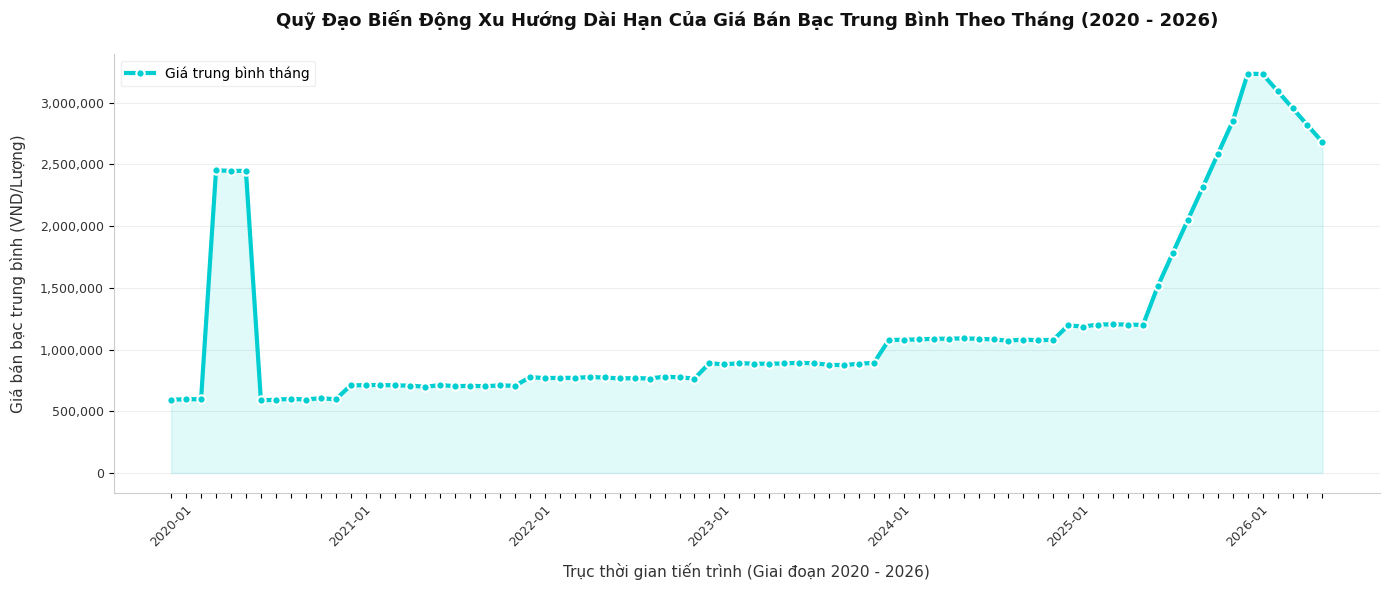

In [26]:
df_q4 = df.groupby(['Nam', 'Thang'])['Gia_Ban'].mean().reset_index()

# Tạo cột trục thời gian định dạng Chuỗi (Ví dụ: "2020-01", "2020-02"...) để hiển thị tuần tự
df_q4['Thoi_Gian'] = df_q4['Nam'].astype(str) + '-' + df_q4['Thang'].astype(str).str.zfill(2)
df_q4 = df_q4.sort_values('Thoi_Gian')

# SỬ DỤNG THEME NỀN TRẮNG SÁNG TIÊU CHUẨN
plt.style.use('default') 

# 2. Khởi tạo cấu hình giao diện đồ thị nền trắng
plt.figure(figsize=(14, 6), facecolor='#ffffff')
ax = plt.gca()
ax.set_facecolor('#ffffff')

# 3. Vẽ biểu đồ đường xu hướng ĐẬM SẮC NÉT
plt.plot(
    df_q4['Thoi_Gian'], 
    df_q4['Gia_Ban'], 
    color='#00ced1',       # Màu xanh ngọc lục bảo (Cyan) tương phản mạnh trên nền trắng
    linewidth=3.0,         # Tăng độ dày đường để nhìn rõ ràng, chắc chắn
    marker='o',            # Chấm tròn lớn tại các mốc tháng
    markersize=6,
    markerfacecolor='#00ced1',
    markeredgecolor='#ffffff', # Viền trắng bao quanh chấm để tạo điểm nhấn tách biệt với đường line
    markeredgewidth=1.5,
    label='Giá trung bình tháng',
    zorder=3
)

# ĐỔ BÓNG GRADIENT MỜ DƯỚI ĐƯỜNG (Giúp biểu đồ có chiều sâu, sáng sủa)
plt.fill_between(
    df_q4['Thoi_Gian'], 
    df_q4['Gia_Ban'], 
    color='#00ced1', 
    alpha=0.12,            # Độ mờ vừa phải để không làm tối biểu đồ
    zorder=2
)

# 4. Định dạng hiển thị trục X (Chỉ hiện nhãn của tháng 1 hàng năm để tránh dày đặc chữ)
x_ticks = df_q4['Thoi_Gian'].tolist()
visible_ticks = [label if '-01' in label else '' for label in x_ticks]
plt.xticks(range(len(x_ticks)), visible_ticks, rotation=45, fontsize=9, color='#333333')
plt.yticks(fontsize=9, color='#333333')

# 5. Cấu hình tiêu đề mới và hệ lưới mờ tinh tế
plt.title('Quỹ Đạo Biến Động Xu Hướng Dài Hạn Của Giá Bán Bạc Trung Bình Theo Tháng (2020 - 2026)', fontsize=13, fontweight='bold', pad=20, color='#111111')
plt.xlabel('Trục thời gian tiến trình (Giai đoạn 2020 - 2026)', fontsize=11, labelpad=10, color='#333333')
plt.ylabel('Giá bán bạc trung bình (VND/Lượng)', fontsize=11, labelpad=10, color='#333333')

# Định dạng hiển thị số tiền có dấu phẩy phân cách trực quan
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))

# Chỉnh đường lưới ngang mảnh, màu xám rất nhạt (Tránh kẻ ô vuông gây rối mắt)
plt.grid(True, axis='y', linestyle='-', alpha=0.3, color='#cccccc', zorder=1)

# LOẠI BỎ VIỀN HỘP BIỂU ĐỒ (Tạo không gian mở, hiện đại)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')   # Làm mờ đường viền trục dọc
ax.spines['bottom'].set_color('#cccccc') # Làm mờ đường viền trục ngang

# Tùy chỉnh hộp chú thích tối giản
plt.legend(loc='upper left', frameon=True, facecolor='#ffffff', edgecolor='#ececec', fontsize=10)

# 6. Tối ưu hóa viền và xuất file ảnh hệ thống
plt.tight_layout()
plt.savefig('cau3_hinh3_4_xu_huong.png', dpi=300, facecolor='#ffffff', edgecolor='none')
plt.show()


# HÌNH 3.5

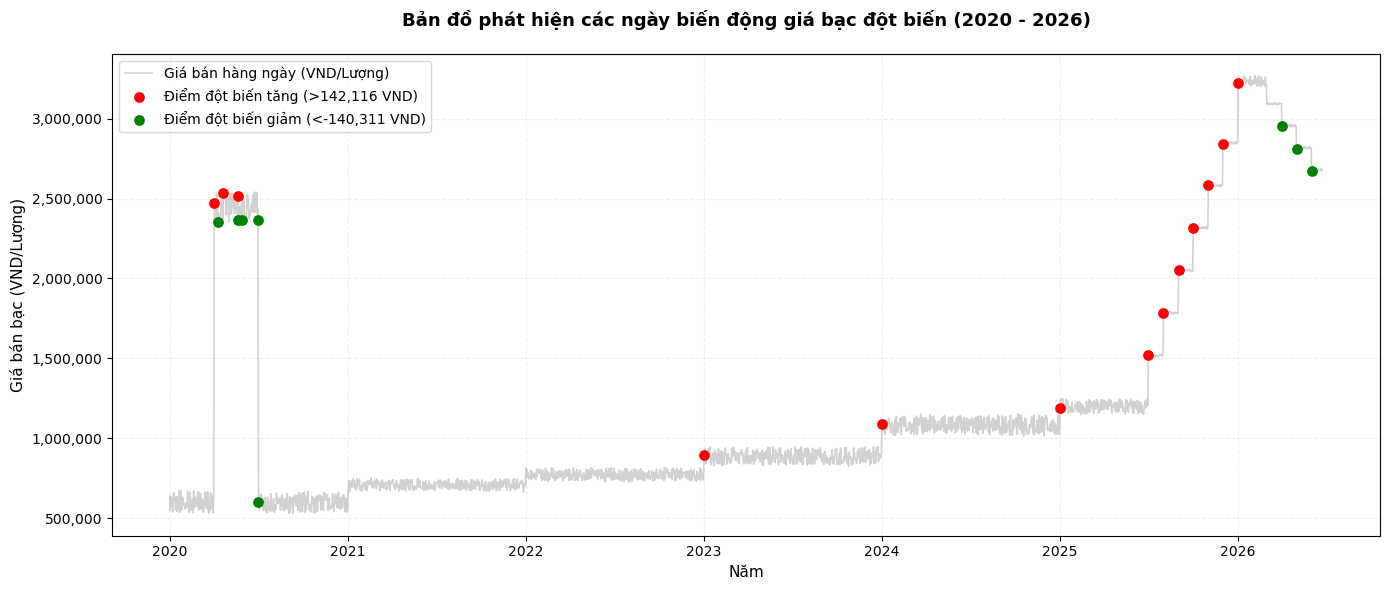

Đã phát hiện 13 phiên tăng sốc và 8 phiên giảm sâu.


In [27]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("default")

df = df.sort_values("Ngay").reset_index(drop=True)
df["Ngay_dt"] = pd.to_datetime(df["Ngay"])

df["Bien_Dong_Hang_Ngay"] = df["Gia_Ban"].diff()

mean_bd = df["Bien_Dong_Hang_Ngay"].mean()
std_bd = df["Bien_Dong_Hang_Ngay"].std()

nguong_tren = mean_bd + 2 * std_bd
nguong_duoi = mean_bd - 2 * std_bd

df_tang_doc = df[df["Bien_Dong_Hang_Ngay"] > nguong_tren]
df_giam_soc = df[df["Bien_Dong_Hang_Ngay"] < nguong_duoi]

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.plot(
    df["Ngay_dt"],
    df["Gia_Ban"],
    color="gray",
    alpha=0.35,
    linewidth=1.2,
    label="Giá bán hàng ngày (VND/Lượng)",
)

ax.scatter(
    df_tang_doc["Ngay_dt"],
    df_tang_doc["Gia_Ban"],
    color="red",
    s=45,
    zorder=5,
    label=f"Điểm đột biến tăng (>{int(nguong_tren):,} VND)",
)

ax.scatter(
    df_giam_soc["Ngay_dt"],
    df_giam_soc["Gia_Ban"],
    color="green",
    s=45,
    zorder=5,
    label=f"Điểm đột biến giảm (<{int(nguong_duoi):,} VND)",
)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=0, fontsize=10)

plt.title(
    "Bản đồ phát hiện các ngày biến động giá bạc đột biến (2020 - 2026)",
    fontsize=13,
    fontweight="bold",
    pad=20,
)

plt.xlabel("Năm", fontsize=11)
plt.ylabel("Giá bán bạc (VND/Lượng)", fontsize=11)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: format(int(x), ","))
)

plt.grid(True, linestyle="--", alpha=0.2)
plt.legend(loc="upper left", fontsize=10)

plt.tight_layout()
plt.savefig("cau3_hinh3_5_dot_bien_chuan.png", dpi=300)
plt.show()

print(
    f"Đã phát hiện {len(df_tang_doc)} phiên tăng sốc và {len(df_giam_soc)} phiên giảm sâu."
)